## Imports and Reproducibility Setup

In [137]:
import pandas as pd 
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Load and Merge Dataset

In [138]:
# # Load the data
# companies = pd.read_csv("../data/raw/objects.csv", low_memory=False)
# rounds = pd.read_csv("../data/raw/funding_rounds.csv", low_memory=False)
# investments = pd.read_csv("../data/raw/investments.csv", low_memory=False)

In [139]:
# # Join the dataframes on the company id
# companies = companies.rename(columns={'id': 'object_id'})

# # --- Aggregate rounds → one row per company ---
# rounds_agg = rounds.groupby('object_id').agg(
#     num_rounds        = ('id', 'count'),
#     total_raised_usd  = ('raised_amount_usd', 'sum'),
#     first_funding_at  = ('funded_at', 'min'),
#     last_funding_at   = ('funded_at', 'max'),
#     round_types       = ('funding_round_type', lambda x: list(x.dropna().unique()))
# ).reset_index()

# # --- Aggregate investments → one row per company ---
# investments_agg = investments.groupby('funded_object_id').agg(
#     num_investors     = ('investor_object_id', 'nunique'),
#     num_invest_rounds = ('funding_round_id', 'nunique')
# ).reset_index().rename(columns={'funded_object_id': 'object_id'})

# # --- Now merge cleanly (all 1:1 at this point) ---
# df = companies.merge(rounds_agg,      on='object_id', how='left')
# df = df.merge(investments_agg,      on='object_id', how='left')

# # --- Verify: should equal len(companies) ---
# assert len(df) == len(companies), f"Duplicates detected! {len(df)} vs {len(companies)}"

In [140]:
# # Inspect resulting dataframe
# print(companies.shape)
# print(companies.columns.tolist())
# print(companies.dtypes)

# # Convert to parquet
# companies.to_parquet("../data/processed/combined.parquet", index=False, engine="fastparquet")

# Read back from parquet (much faster for subsequent loads)
df = pd.read_parquet("../data/processed/combined.parquet")

In [141]:
df.head()

,object_id,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,founded_at,...,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at
0,c:1,Company,1,None,Wetpaint,wetpaint,/company/wetpaint,web,operating,2005-10-17,...,2008-05-19,3,39750000.0,2010-09-05,2013-09-18,5,17,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00
1,c:10,Company,10,None,Flektor,flektor,/company/flektor,games_video,acquired,None,...,None,0,0.0,None,None,0,6,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14
2,c:100,Company,100,None,There,there,/company/there,games_video,acquired,None,...,None,0,0.0,2003-02-01,2011-09-23,4,12,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48
3,c:10000,Company,10000,None,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,2008-07-26,...,None,0,0.0,None,None,0,0,None,2008-08-24 16:51:57,2008-09-06 14:19:18
4,c:10001,Company,10001,None,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,2008-07-26,...,None,0,0.0,None,None,0,0,None,2008-08-24 17:10:34,2008-09-06 14:19:18


### Examine Duplicates

In [142]:
# Find rows where id is duplicated
duplicate_ids = df[df.duplicated(subset=["object_id"], keep=False)]["object_id"].unique()
print(f"Number of duplicate ids: {len(duplicate_ids)}")
print(f"Example duplicate ids: {duplicate_ids[:5]}")

# Find differences between rows with the same id
for dup_id in duplicate_ids[:5]:  # Check first 5 duplicate ids
    dup_rows = df[df["id"] == dup_id]
    print(f"\nDuplicate rows for id {dup_id}:")
    print(dup_rows)

Number of duplicate ids: 0
Example duplicate ids: []


In [143]:
len(df)

462651

## Filter rows based on `status`
**Success** = `acquired` or `ipo`
**Failure** = `closed`
**Exclude** = `operating` (outcome unknown at snapshot time)

In [144]:
# Filter rows with KNOWN outcomes only (status = acquired / ipo / closed)
df = df[df['status'].isin(['acquired', 'ipo', 'closed'])]
len(df)

13301

In [145]:
# Find rows where column 'overview' is at least 500 characters long
long_overviews = df[df["overview"].str.len() >= 500]
df = long_overviews
print(len(df))

5813


In [146]:
# Number of successful vs unsuccessful outcomes
df['status'].value_counts()

status
acquired    3816
closed      1197
ipo          800
Name: count, dtype: int64

In [149]:
# Create binary target variable: 1 for successful (acquired/ipo), 0 for unsuccessful (closed)
df['target'] = df['status'].apply(lambda x: 1 if x in ['acquired', 'ipo'] else 0)
df['target'].value_counts()

target
1    4616
0    1197
Name: count, dtype: int64

## Data Exploration

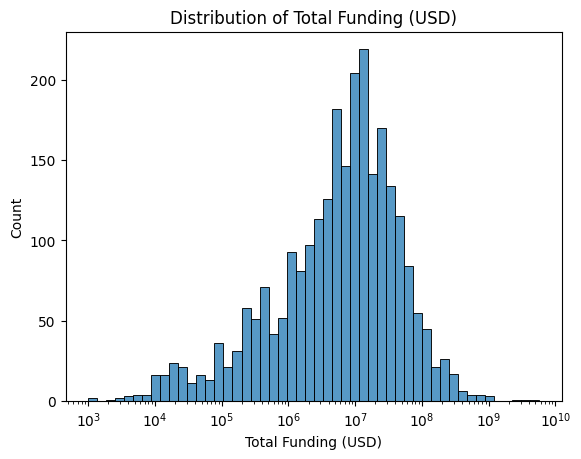

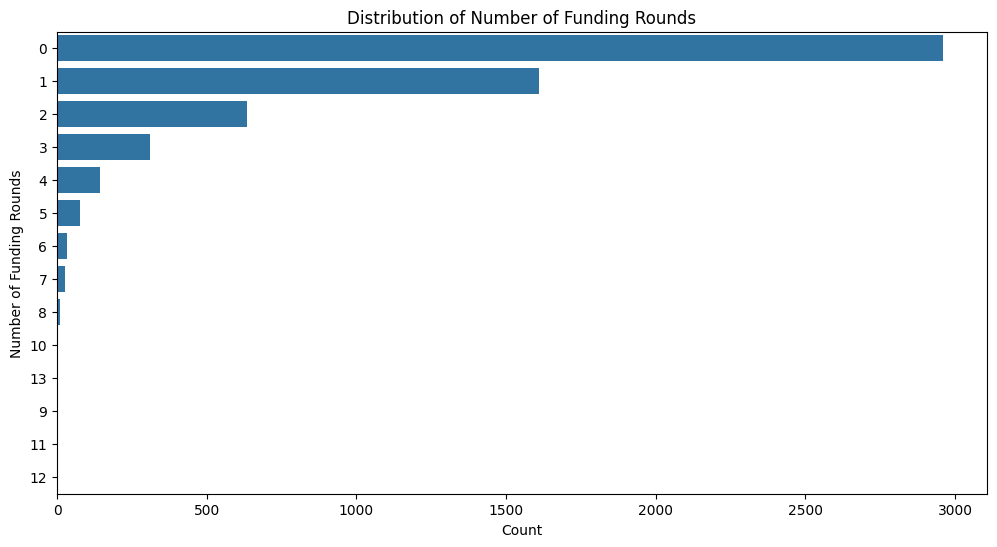

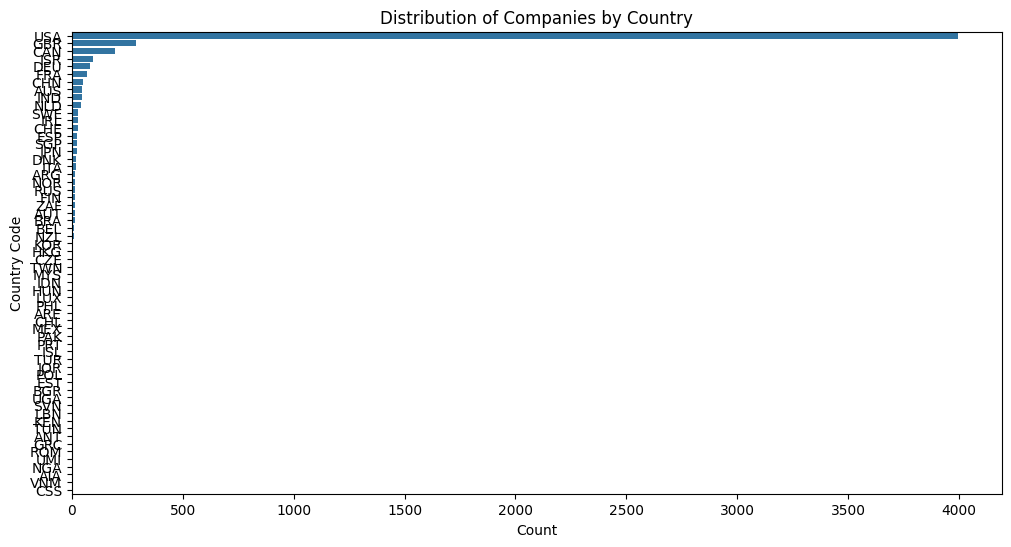

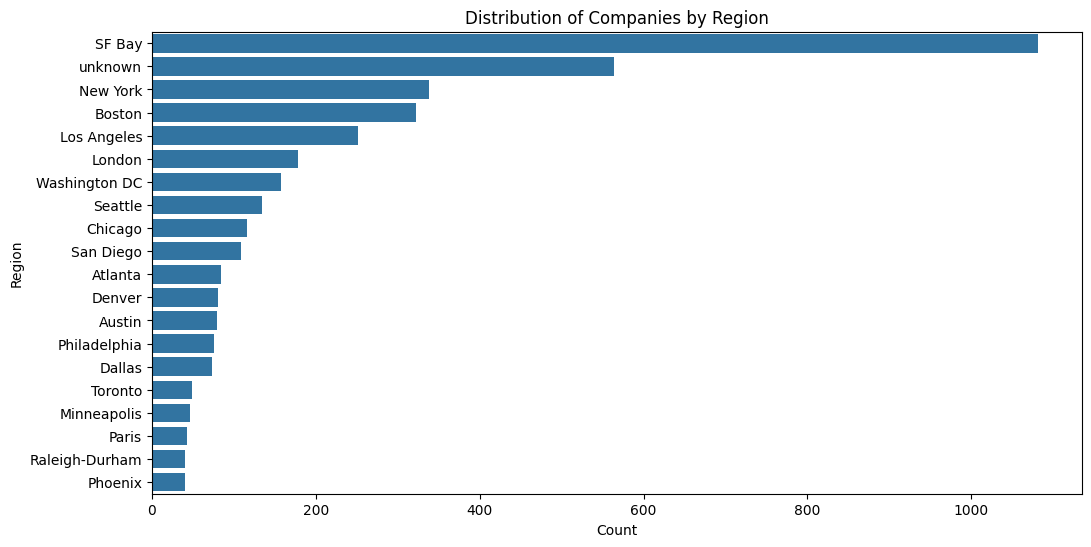

In [147]:
# Plot feature distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of total funding (log scale)
sns.histplot(df['funding_total_usd'], bins=50, log_scale=True)
plt.title("Distribution of Total Funding (USD)")
plt.xlabel("Total Funding (USD)")
plt.ylabel("Count")
plt.show()

# Plot distrobution of funding rounds
plt.figure(figsize=(12, 6))
sns.countplot(y='funding_rounds', data=df, order=df['funding_rounds'].value_counts().index)
plt.title("Distribution of Number of Funding Rounds")
plt.xlabel("Count")
plt.ylabel("Number of Funding Rounds")
plt.show()

# Plot distribution of countries 
plt.figure(figsize=(12, 6))
sns.countplot(y='country_code', data=df, order=df['country_code'].value_counts().index)
plt.title("Distribution of Companies by Country")
plt.xlabel("Count")
plt.ylabel("Country Code")
plt.show()

# Plot distribution of regions (limit to top 20) 
plt.figure(figsize=(12, 6))
sns.countplot(y='region', data=df, order=df['region'].value_counts().index[:20])
plt.title("Distribution of Companies by Region")
plt.xlabel("Count")
plt.ylabel("Region")
plt.show()



## Missing Value Analysis

In [148]:
# Print full missing-values summary 
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary.to_string())

parent_id              5768
last_investment_at     5580
first_investment_at    5580
short_description      5228
closed_at              4592
tag_list               3615
twitter_username       3505
first_funding_at       2988
last_funding_at        2988
description            2636
first_milestone_at     2330
last_milestone_at      2330
state_code             1860
founded_at             1601
created_by             1277
city                    659
category_code           559
logo_url                554
country_code            526
domain                  373
homepage_url            373
entity_type               0
object_id                 0
entity_id                 0
permalink                 0
normalized_name           0
name                      0
logo_width                0
logo_height               0
overview                  0
status                    0
investment_rounds         0
funding_rounds            0
invested_companies        0
region                    0
funding_total_usd   

### Missing Value Handling

**Impute**
- category_code       559   (10%)  ← impute with "unknown"
- country_code        526   ( 9%)  ← impute with "unknown"
- city                659   (11%)  ← impute with "unknown"
- founded_at        1,601   (28%)  ← impute with median, add missing flag
- first_funding_at  2,988   (51%)  ← add binary "has_funding_date" flag
- last_funding_at   2,988   (51%)  ← same

**Drop?**
- parent_id          5,768  (99%)
- last_investment_at 5,580  (96%)
- first_investment_at 5,580 (96%)
- closed_at          4,592  (79%)  ← leakage risk anyway
- tag_list           3,615  (62%)
- twitter_username   3,505  (60%)
- first_milestone_at 2,330  (40%)
- last_milestone_at  2,330  (40%)
- state_code         1,860  (32%)  ← use region instead

In [ ]:

# --- Type casting (safe: no statistics derived from data) ---
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')

# --- Drop columns: high missingness, leakage, or pure metadata ---
# Imputation decisions for remaining columns are deferred to the training pipeline
# (fit on train split only, then transform train and test separately).
#
# Planned imputation strategy (to be implemented in pipeline):
#   category_code / country_code / city  → fill with "unknown"
#   founded_at                           → median imputation + add founded_at_missing flag
#   first_funding_at / last_funding_at   → add has_funding_date binary flag, leave dates as NaT
cols_to_drop = [
    'parent_id',            # 99% missing
    'last_investment_at',   # 96% missing
    'first_investment_at',  # 96% missing
    'closed_at',            # leakage: directly encodes outcome timing
    'tag_list',             # 62% missing
    'twitter_username',     # 60% missing
    'first_milestone_at',   # 40% missing — milestones count already captured
    'last_milestone_at',    # 40% missing
    'state_code',           # redundant with region
    'logo_url', 'logo_width', 'logo_height',
    'domain', 'homepage_url', 'permalink',
    'normalized_name', 'entity_id', 'created_by',
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
print("\nRemaining missing values (to be handled in training pipeline):")
missing = df.isnull().sum()
print(missing[missing > 0].to_string())


## Filter to US-based Companies

US companies dominate the dataset (~80%+). Keeping only US companies removes geographic noise and aligns with the Crunchbase snapshot's strongest coverage. We document the class balance at each filter stage to catch selection bias.

In [ ]:

# Filter to US only
df_us = df[df['country_code'] == 'USA'].copy()

print(f"Total after previous filters : {len(df)}")
print(f"US companies                 : {len(df_us)}")
print(f"Dropped (non-US)             : {len(df) - len(df_us)}\n")

print("Class balance (US only):")
print(df_us['target'].value_counts())
print(f"\nSuccess rate: {df_us['target'].mean():.1%}")


## Save Final Processed Dataset

In [ ]:

df_us.to_parquet("../data/processed/companies_clean.parquet", index=False)

print(f"Saved {len(df_us)} rows, {df_us.shape[1]} columns")
print(f"Path: data/processed/companies_clean.parquet")
print(f"\nColumns saved:")
for col in df_us.columns:
    print(f"  {col}")


In [ ]:
# Display the 'overview' column of one of those rows
print(long_overviews["overview"].iloc[100])

Proofpoint provides cloud-based email security, eDiscovery and compliance solutions. Its patented technologies and on-demand delivery system protect against spam and viruses, safeguard privacy, encrypt sensitive information, and archive messages for management and discovery. 


SAAS SECURITY & COMPLIANCE SUITE

Enterprise Email Archiving: The email archiving solution supports eDiscovery, regulatory compliance and email storage management.

Enterprise Email Protection:  Provides inbound and outbound email security and management to protect from outside threats including spam, phishing, unpredictable email volumes, malware and other forms of objectionable or dangerous content before they hit the enterprise perimeter. 

Enterprise Privacy: Protects private information in email, defends against leaks of confidential information and ensures compliance with common international, industry and US data protection regulationsâincluding HIPAA, GLBA and PCI-DSS.

PRODUCT ADD-ONS

Policy-Based Em